# Configuration Selection Ã¢â‚¬â€ Thesis

**Recommended configuration:** `mcgs, num_rollouts=64, c=1.4, alpha=0.0`

Three questions are answered:
1. **Effect of `num_rollouts`** Ã¢â‚¬â€ does more rollouts help, and does the benefit saturate?
2. **Effect of `c` (exploration constant)** Ã¢â‚¬â€ which value balances exploration vs exploitation?
3. **Effect of `alpha`** Ã¢â‚¬â€ does the prior weighting matter?

For each parameter we show (a) a bar chart of mean `rel_drop` at the highest rollout setting and
(b) the scaling curve Ã¢â‚¬â€ how mean `rel_drop` changes as the evaluation budget grows.
Differences between configurations are small relative to inter-image variability
(variance decomposition shows >95% of total variance is between images, not between configs),
so we present means as descriptive summaries and do not rely on significance tests for the final choice.

## Setup

In [25]:
import os

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns


MLFLOW_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENTS = {
    "mcts": "mcts-grid-thesis",
    "mcgs": "mcgs-grid-thesis",
}

os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

mlflow.set_tracking_uri(MLFLOW_URI)
client = mlflow.MlflowClient()
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

RECOMMENDED = {"algorithm": "mcgs", "num_rollouts": 64, "c": 1.4, "alpha": 0.0}
REC_COLOR = "tab:red"
ALGO_COLOR = {"mcgs": "#2196F3", "mcts": "#FF9800"}

In [26]:
def load_experiment(algo, exp_name):
    exp = client.get_experiment_by_name(exp_name)
    if exp is None:
        print(f"[warn] not found: {exp_name}")
        return pd.DataFrame()
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id], max_results=10000, output_format="pandas"
    )
    if not runs.empty:
        runs["algorithm"] = algo
    return runs


all_runs = pd.concat(
    [load_experiment(a, n) for a, n in EXPERIMENTS.items()], ignore_index=True
)

PARENT_TAG = "tags.mlflow.parentRunId"
child_runs = all_runs[all_runs[PARENT_TAG].notna()].copy()
parent_runs = all_runs[all_runs[PARENT_TAG].isna()].copy()

parent_param_cols = sorted(c for c in parent_runs.columns if c.startswith("params."))
child_runs = child_runs.drop(
    columns=[c for c in parent_param_cols if c in child_runs.columns]
)
child_runs = child_runs.join(
    parent_runs.set_index("run_id")[parent_param_cols], on=PARENT_TAG
)

for col in parent_param_cols:
    if col in child_runs.columns:
        child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")
for col in [c for c in child_runs.columns if c.startswith("metrics.")]:
    child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")

child_runs = child_runs.rename(
    columns={
        "params.method.num_rollouts": "num_rollouts",
        "params.method.exploration_c": "c",
        "params.method.alpha": "alpha",
        "metrics.region_0/probability_drop": "prob_drop",
        "metrics.region_0/evaluations_count": "evals_used",
        "metrics.region_0/original_prob": "original_prob",
        "metrics.time_seconds": "time_s",
        "tags.mlflow.runName": "image_name",
    }
)
child_runs["rel_drop"] = child_runs["prob_drop"] / child_runs["original_prob"]

needed = [
    "algorithm",
    "num_rollouts",
    "c",
    "alpha",
    "image_name",
    "prob_drop",
    "rel_drop",
    "original_prob",
    "evals_used",
]
child_runs = child_runs.dropna(subset=needed).reset_index(drop=True)

GROUP = ["algorithm", "num_rollouts", "c", "alpha"]
agg = (
    child_runs.groupby(GROUP)[["rel_drop", "prob_drop", "evals_used", "time_s"]]
    .agg(["mean", "std"])
    .reset_index()
)
agg.columns = ["_".join(c).rstrip("_") for c in agg.columns]

print(f"Loaded {len(child_runs)} per-image runs, {len(agg)} configurations.")

Loaded 2700 per-image runs, 90 configurations.


## Effect of algorithm (MCTS vs MCGS)

Before examining individual parameters, we check whether the choice of algorithm matters at all.

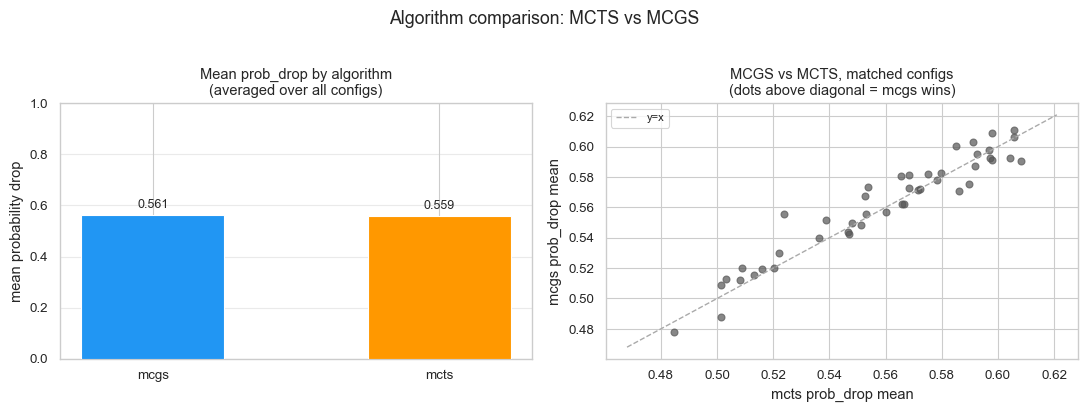

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: mean prob_drop per algorithm, collapsed over all (c, alpha, rollouts)
ax = axes[0]
algo_means = agg.groupby("algorithm")["prob_drop_mean"].mean()
bars = ax.bar(
    algo_means.index,
    algo_means.values,
    color=[ALGO_COLOR[a] for a in algo_means.index],
    width=0.5,
    zorder=3,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylabel("mean probability drop")
ax.set_title("Mean prob_drop by algorithm\n(averaged over all configs)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.4)

# Right: per-config scatter, mcgs vs mcts for matched (rollouts, c, alpha)
ax = axes[1]
mcgs = agg[agg["algorithm"] == "mcgs"].set_index(["num_rollouts", "c", "alpha"])[
    "prob_drop_mean"
]
mcts = agg[agg["algorithm"] == "mcts"].set_index(["num_rollouts", "c", "alpha"])[
    "prob_drop_mean"
]
common = mcgs.index.intersection(mcts.index)
ax.scatter(mcts.loc[common], mcgs.loc[common], s=25, alpha=0.7, color="#555")
lims = [
    min(mcts.loc[common].min(), mcgs.loc[common].min()) - 0.01,
    max(mcts.loc[common].max(), mcgs.loc[common].max()) + 0.01,
]
ax.plot(lims, lims, "--", color="#aaa", linewidth=1, label="y=x")
ax.set_xlabel("mcts prob_drop mean")
ax.set_ylabel("mcgs prob_drop mean")
ax.set_title("MCGS vs MCTS, matched configs\n(dots above diagonal = mcgs wins)")
ax.legend(fontsize=8)

fig.suptitle("Algorithm comparison: MCTS vs MCGS", y=1.02)
fig.tight_layout()
plt.show()

## Effect of `num_rollouts`

`num_rollouts` controls how many simulation trajectories are run per tree node before selecting a move. More rollouts = better value estimates per step, but also more evaluations per step. We test $r \in \{1, 16, 64\}$.

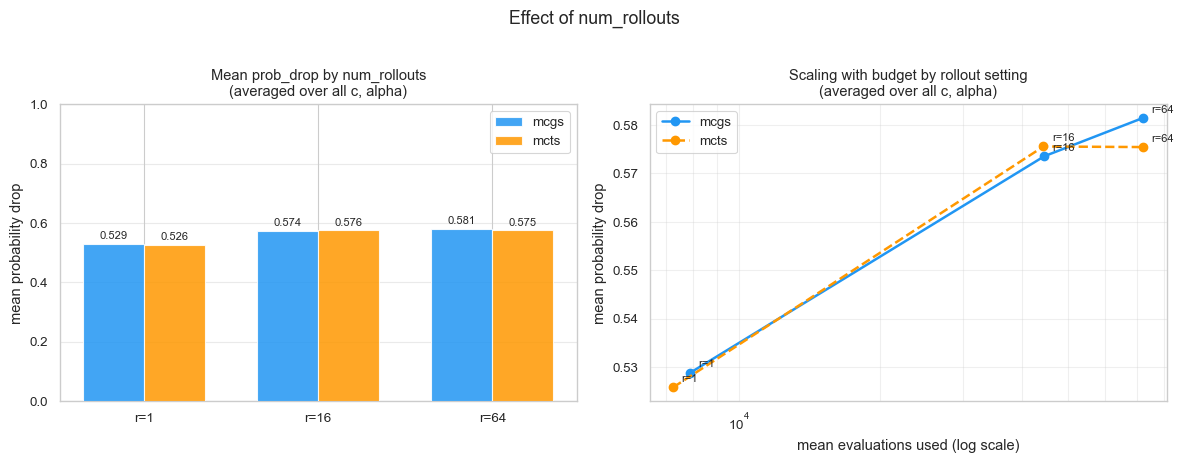

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rollout_vals = sorted(agg["num_rollouts"].unique())
rollout_colors = sns.color_palette("Blues_d", n_colors=len(rollout_vals))
r_to_color = dict(zip(rollout_vals, rollout_colors, strict=False))

# Left: mean prob_drop per rollout setting, one bar per algo
ax = axes[0]
x = np.arange(len(rollout_vals))
width = 0.35
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = agg[agg["algorithm"] == algo].groupby("num_rollouts")["prob_drop_mean"].mean()
    sub = sub.reindex(rollout_vals)
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"r={int(r)}" for r in rollout_vals])
ax.set_ylabel("mean probability drop")
ax.set_title("Mean prob_drop by num_rollouts\n(averaged over all c, alpha)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.4)

# Right: scaling curve Ã¢â‚¬â€ prob_drop vs evals, one line per rollout, averaged over all (c, alpha)
ax = axes[1]
for algo, ls in [("mcgs", "-"), ("mcts", "--")]:
    sub = (
        agg[agg["algorithm"] == algo]
        .groupby("num_rollouts")
        .agg(
            evals=pd.NamedAgg("evals_used_mean", "mean"),
            prob_drop=pd.NamedAgg("prob_drop_mean", "mean"),
        )
        .reset_index()
    )
    ax.plot(
        sub["evals"],
        sub["prob_drop"],
        marker="o",
        linestyle=ls,
        color=ALGO_COLOR[algo],
        linewidth=1.8,
        markersize=6,
        label=algo,
    )
    for _, row in sub.iterrows():
        ax.annotate(
            f"r={int(row['num_rollouts'])}",
            (row["evals"], row["prob_drop"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
        )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean probability drop")
ax.set_title("Scaling with budget by rollout setting\n(averaged over all c, alpha)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of num_rollouts", y=1.02)
fig.tight_layout()
plt.show()

## Effect of `c` (exploration constant)

`c` is the UCB exploration constant. A high value encourages the tree to explore under-visited nodes; a low value exploits already-promising branches. We test $c \in \{0.1, 0.7, 1.4, 3.0, 5.0\}$.

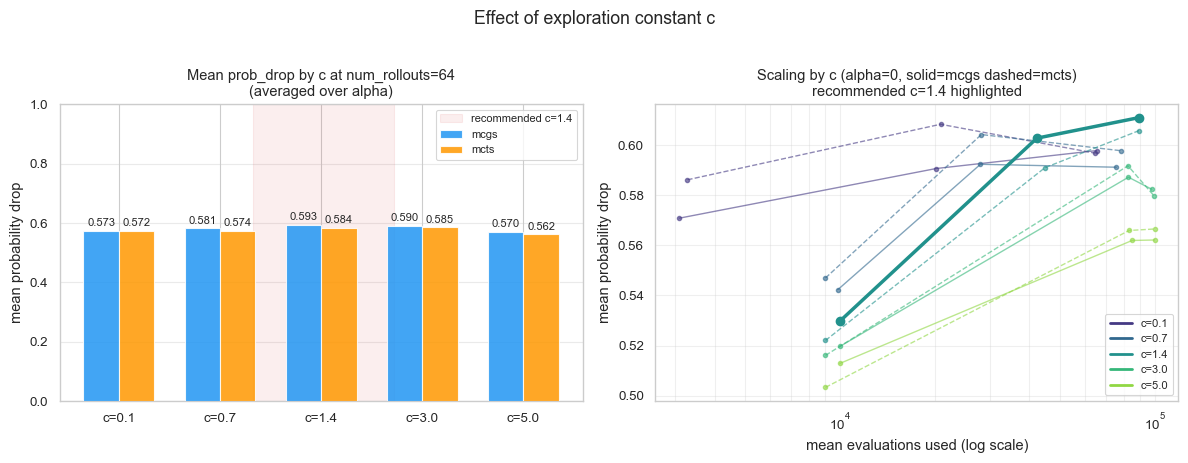

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
c_vals = sorted(agg["c"].unique())
c_palette = sns.color_palette("viridis", n_colors=len(c_vals))
c_to_color = dict(zip(c_vals, c_palette, strict=False))

# Left: mean prob_drop per c, at r=64 only, one bar per algo
ax = axes[0]
r64 = agg[agg["num_rollouts"] == 64]
x = np.arange(len(c_vals))
width = 0.35
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = (
        r64[r64["algorithm"] == algo]
        .groupby("c")["prob_drop_mean"]
        .mean()
        .reindex(c_vals)
    )
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
# Highlight recommended c
rec_c_idx = c_vals.index(RECOMMENDED["c"])
ax.axvspan(
    rec_c_idx - 0.5,
    rec_c_idx + 0.9,
    color=REC_COLOR,
    alpha=0.08,
    label=f"recommended c={RECOMMENDED['c']}",
)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"c={c}" for c in c_vals])
ax.set_ylabel("mean probability drop")
ax.set_title("Mean prob_drop by c at num_rollouts=64\n(averaged over alpha)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# Right: scaling curves per c, mcgs only, alpha=0
ax = axes[1]
for algo, ls in [("mcgs", "-"), ("mcts", "--")]:
    sub = agg[(agg["algorithm"] == algo) & (agg["alpha"] == 0.0)]
    for c_val, grp in sub.groupby("c"):
        grp = grp.sort_values("evals_used_mean")
        is_rec = algo == RECOMMENDED["algorithm"] and c_val == RECOMMENDED["c"]
        ax.plot(
            grp["evals_used_mean"],
            grp["prob_drop_mean"],
            color=c_to_color[c_val],
            linestyle=ls,
            linewidth=2.5 if is_rec else 1.0,
            alpha=1.0 if is_rec else 0.6,
            marker="o",
            markersize=6 if is_rec else 3,
            zorder=5 if is_rec else 2,
        )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean probability drop")
ax.set_title(
    "Scaling by c (alpha=0, solid=mcgs dashed=mcts)\nrecommended c=1.4 highlighted"
)
c_handles = [
    plt.Line2D([], [], color=c_to_color[c], linewidth=2, label=f"c={c}") for c in c_vals
]
ax.legend(handles=c_handles, fontsize=8, loc="lower right")
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of exploration constant c", y=1.02)
fig.tight_layout()
plt.show()

## Effect of `alpha`

`alpha` weights a prior over which segments to mask. `alpha=0` means no prior (uniform); `alpha=1` means the prior dominates. We test $\alpha \in \{0.0, 0.5, 1.0\}$.

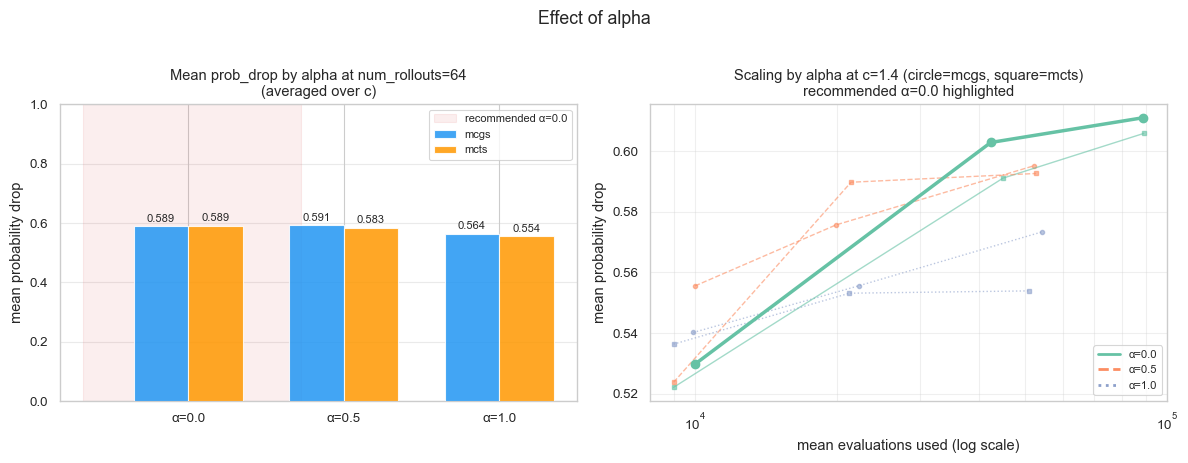

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
alpha_vals = sorted(agg["alpha"].unique())
alpha_colors = sns.color_palette("Set2", n_colors=len(alpha_vals))
a_to_color = dict(zip(alpha_vals, alpha_colors, strict=False))

# Left: mean prob_drop per alpha, at r=64, one bar per algo
ax = axes[0]
x = np.arange(len(alpha_vals))
width = 0.35
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = (
        r64[r64["algorithm"] == algo]
        .groupby("alpha")["prob_drop_mean"]
        .mean()
        .reindex(alpha_vals)
    )
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
rec_a_idx = alpha_vals.index(RECOMMENDED["alpha"])
ax.axvspan(
    rec_a_idx - 0.5,
    rec_a_idx + 0.9,
    color=REC_COLOR,
    alpha=0.08,
    label=f"recommended ÃŽÂ±={RECOMMENDED['alpha']}",
)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"ÃŽÂ±={a}" for a in alpha_vals])
ax.set_ylabel("mean probability drop")
ax.set_title("Mean prob_drop by alpha at num_rollouts=64\n(averaged over c)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# Right: scaling curves per alpha, at recommended c, both algos
ax = axes[1]
alpha_to_ls = {0.0: "-", 0.5: "--", 1.0: ":"}
for algo, marker in [("mcgs", "o"), ("mcts", "s")]:
    sub = agg[(agg["algorithm"] == algo) & (agg["c"] == RECOMMENDED["c"])]
    for alpha_val, grp in sub.groupby("alpha"):
        grp = grp.sort_values("evals_used_mean")
        is_rec = algo == RECOMMENDED["algorithm"] and alpha_val == RECOMMENDED["alpha"]
        ax.plot(
            grp["evals_used_mean"],
            grp["prob_drop_mean"],
            color=a_to_color[alpha_val],
            linestyle=alpha_to_ls[alpha_val],
            linewidth=2.5 if is_rec else 1.0,
            alpha=1.0 if is_rec else 0.6,
            marker=marker,
            markersize=6 if is_rec else 3,
            zorder=5 if is_rec else 2,
        )
ax.set_xscale("log")
ax.set_xlabel("mean evaluations used (log scale)")
ax.set_ylabel("mean probability drop")
ax.set_title(
    f"Scaling by alpha at c={RECOMMENDED['c']} (circle=mcgs, square=mcts)\nrecommended ÃŽÂ±=0.0 highlighted"
)
a_handles = [
    plt.Line2D(
        [],
        [],
        color=a_to_color[a],
        linestyle=alpha_to_ls[a],
        linewidth=2,
        label=f"ÃŽÂ±={a}",
    )
    for a in alpha_vals
]
ax.legend(handles=a_handles, fontsize=8, loc="lower right")
ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Effect of alpha", y=1.02)
fig.tight_layout()
plt.show()

## Summary table

Final numerical summary of the recommended configuration.

In [31]:
rec = agg[
    (agg["algorithm"] == RECOMMENDED["algorithm"])
    & (agg["num_rollouts"] == RECOMMENDED["num_rollouts"])
    & (agg["c"] == RECOMMENDED["c"])
    & (agg["alpha"] == RECOMMENDED["alpha"])
].iloc[0]

r64_all = agg[agg["num_rollouts"] == 64]
rank_rel = int((r64_all["rel_drop_mean"] > rec["rel_drop_mean"]).sum() + 1)
n_total = len(r64_all)

pd.Series(
    {
        "algorithm": RECOMMENDED["algorithm"],
        "num_rollouts": int(RECOMMENDED["num_rollouts"]),
        "c": RECOMMENDED["c"],
        "alpha": RECOMMENDED["alpha"],
        "rel_drop_mean": round(rec["rel_drop_mean"], 4),
        "rel_drop_std": round(rec["rel_drop_std"], 4),
        "prob_drop_mean": round(rec["prob_drop_mean"], 4),
        "evals_used_mean": int(rec["evals_used_mean"]),
        "evals_used_std": round(rec["evals_used_std"], 0),
        "time_s_mean": round(rec["time_s_mean"], 1),
        "rank_among_r64_configs": f"{rank_rel} / {n_total}",
    }
).to_frame("value")

,value
algorithm,mcgs
num_rollouts,64
c,1.4
alpha,0.0
rel_drop_mean,0.759
rel_drop_std,0.3407
prob_drop_mean,0.611
evals_used_mean,88983
evals_used_std,13764.0
time_s_mean,25.1


## Per-image normalized scores & win counts

For each image, `rel_drop` is normalized to [0, 1] across all configs for that image (0 = worst, 1 = best). This mirrors the metric used in `compare_algorithms_imagenet_s`.

**Win counting:** for each image, the config with the highest normalized score wins. Two variants: no threshold (all images produce a winner) and a decisive-margin threshold (winner must exceed 2nd place by at least `WIN_MARGIN`).

Results are shown for all configs combined (table) and for the highest-budget tier (bar charts).

### Average rank (mean rank)

When per-image drops are very heterogeneous or have outliers, a rank-based summary is more robust than absolute values. Each image ranks configs from 1 (best `rel_drop`) to N (worst). The mean rank across images is then reported; lower is better and scale-free.

In [32]:
WIN_MARGIN = 0.05  # minimum normalized-score gap for a decisive win


def _add_norm_scores(df):
    def _norm(grp):
        mn, mx = grp["prob_drop"].min(), grp["prob_drop"].max()
        grp = grp.copy()
        grp["norm_score"] = 0.5 if mx == mn else (grp["prob_drop"] - mn) / (mx - mn)
        return grp

    return df.groupby("image_name", group_keys=False).apply(_norm)


def _count_wins(df, margin):
    _G = ["algorithm", "num_rollouts", "c", "alpha"]
    records = []
    for _, grp in df.groupby("image_name"):
        valid = grp.dropna(subset=["norm_score"])
        if len(valid) < 2:
            continue
        ranked = valid.nlargest(len(valid), "norm_score")
        if (
            margin == 0.0
            or (ranked.iloc[0]["norm_score"] - ranked.iloc[1]["norm_score"]) > margin
        ):
            records.append(ranked.iloc[0][_G].to_dict())
    if not records:
        return pd.DataFrame(columns=_G + ["wins"])
    rec = pd.DataFrame(records)
    return rec.groupby(_G).size().reset_index(name="wins")


_GROUP = ["algorithm", "num_rollouts", "c", "alpha"]
child_runs_n = _add_norm_scores(child_runs)


_wins_no = _count_wins(child_runs_n, 0.0)
_wins_mg = _count_wins(child_runs_n, WIN_MARGIN)


norm_sum = (
    child_runs_n.groupby(_GROUP)["norm_score"]
    .agg(norm_score_mean="mean", norm_score_std="std")
    .reset_index()
    .merge(_wins_no.rename(columns={"wins": "wins_no_margin"}), on=_GROUP, how="left")
    .merge(_wins_mg.rename(columns={"wins": "wins_decisive"}), on=_GROUP, how="left")
    .fillna({"wins_no_margin": 0, "wins_decisive": 0})
    .sort_values("norm_score_mean", ascending=False)
    .reset_index(drop=True)
)
norm_sum[["wins_no_margin", "wins_decisive"]] = norm_sum[
    ["wins_no_margin", "wins_decisive"]
].astype(int)

_n_img = child_runs_n["image_name"].nunique()
_n_dec = int(_wins_mg["wins"].sum()) if not _wins_mg.empty else 0
print(
    f"Total images: {_n_img}  |  Decisive winners (margin={WIN_MARGIN}): {_n_dec}/{_n_img}"
)
print("\nTop 15 configs by mean normalized per-image score:")
display(norm_sum.head(15).round(4))


# Mean rank per image (non-parametric)
def _add_ranks(df):
    def _rank(grp):
        grp = grp.copy()
        grp["rank"] = grp["prob_drop"].rank(method="average", ascending=False)
        return grp

    return df.groupby("image_name", group_keys=False).apply(_rank)


ranked = _add_ranks(child_runs_n)


rank_sum = (
    ranked.groupby(_GROUP)["rank"]
    .agg(mean_rank="mean", rank_std="std", n_images="count")
    .reset_index()
    .sort_values("mean_rank")
    .reset_index(drop=True)
)
print("\nTop 15 configs by mean per-image rank (lower is better):")
display(rank_sum.head(15).round(3))

rec_rank = rank_sum[
    (rank_sum["algorithm"] == RECOMMENDED["algorithm"])
    & (rank_sum["num_rollouts"] == RECOMMENDED["num_rollouts"])
    & (rank_sum["c"] == RECOMMENDED["c"])
    & (rank_sum["alpha"] == RECOMMENDED["alpha"])
]
if not rec_rank.empty:
    print(
        "Recommended config mean rank: "
        f"{rec_rank.iloc[0]['mean_rank']:.3f} "
        f"(std={rec_rank.iloc[0]['rank_std']:.3f}, n={int(rec_rank.iloc[0]['n_images'])})"
    )

# Combined ranking across metrics
prob_stats = agg[_GROUP + ["prob_drop_mean", "prob_drop_std"]].copy()
norm_stats = norm_sum[_GROUP + ["norm_score_mean", "norm_score_std"]].copy()
rank_stats = rank_sum[_GROUP + ["mean_rank", "rank_std"]].copy()

combined = prob_stats.merge(norm_stats, on=_GROUP, how="inner").merge(
    rank_stats, on=_GROUP, how="inner"
)
combined["rank_prob_drop"] = (
    combined["prob_drop_mean"].rank(ascending=False, method="min").astype(int)
)
combined["rank_norm_score"] = (
    combined["norm_score_mean"].rank(ascending=False, method="min").astype(int)
)
combined["rank_mean_rank"] = (
    combined["mean_rank"].rank(ascending=True, method="min").astype(int)
)
combined["final_score"] = combined[
    ["rank_prob_drop", "rank_norm_score", "rank_mean_rank"]
].mean(axis=1)


def _fmt_mean_std(mean, std):
    return f"{mean:.4f} Ã‚Â± {std:.4f}"


out = combined.copy()
out["num_rollouts"] = out["num_rollouts"].astype(int)
out["prob_drop"] = out.apply(
    lambda r: _fmt_mean_std(r["prob_drop_mean"], r["prob_drop_std"]), axis=1
)
out["norm_score"] = out.apply(
    lambda r: _fmt_mean_std(r["norm_score_mean"], r["norm_score_std"]), axis=1
)
out["mean_rank"] = out.apply(
    lambda r: _fmt_mean_std(r["mean_rank"], r["rank_std"]), axis=1
)
out["final_score"] = out["final_score"].round(3)

top10 = (
    out[
        [
            "algorithm",
            "num_rollouts",
            "c",
            "alpha",
            "prob_drop",
            "rank_prob_drop",
            "norm_score",
            "rank_norm_score",
            "mean_rank",
            "rank_mean_rank",
            "final_score",
        ]
    ]
    .sort_values("final_score")
    .head(10)
    .reset_index(drop=True)
)
display(top10)

TEMP_DIR/ipykernel_1420\242265235.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("image_name", group_keys=False).apply(_norm)


Total images: 30  |  Decisive winners (margin=0.05): 9/30

Top 15 configs by mean normalized per-image score:


,algorithm,num_rollouts,c,alpha,norm_score_mean,norm_score_std,wins_no_margin,wins_decisive
0,mcgs,16,1.4,0.0,0.8277,0.1830,0,0
1,mcgs,64,1.4,0.0,0.8263,0.1604,2,0
2,mcts,64,1.4,0.0,0.8250,0.1902,3,0
3,mcts,16,0.7,0.0,0.8246,0.2059,3,1
4,mcts,64,0.7,0.0,0.8154,0.2095,1,0
5,mcgs,16,3.0,0.5,0.8149,0.2146,3,2
6,mcgs,64,3.0,0.5,0.8060,0.1586,1,0
7,mcgs,16,0.7,0.0,0.8056,0.2407,0,0
8,mcts,64,0.1,0.0,0.8020,0.2363,1,0
9,mcts,16,1.4,0.0,0.7952,0.1939,1,0



Top 15 configs by mean per-image rank (lower is better):


TEMP_DIR/ipykernel_1420\242265235.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("image_name", group_keys=False).apply(_rank)


,algorithm,num_rollouts,c,alpha,mean_rank,rank_std,n_images
0,mcts,64,0.7,0.0,15.867,15.397,30
1,mcts,64,1.4,0.0,17.300,15.358,30
2,mcgs,64,1.4,0.0,17.783,15.387,30
3,mcgs,16,1.4,0.0,18.200,17.179,30
4,mcts,16,3.0,0.5,18.933,16.088,30
5,mcts,16,0.7,0.0,19.017,17.023,30
6,mcgs,16,0.7,0.0,19.067,16.364,30
7,mcgs,64,3.0,0.5,19.467,14.562,30
8,mcgs,16,3.0,0.5,19.667,18.176,30
9,mcts,64,0.1,0.0,20.867,17.411,30


Recommended config mean rank: 17.783 (std=15.387, n=30)


,algorithm,num_rollouts,c,alpha,prob_drop,rank_prob_drop,norm_score,rank_norm_score,mean_rank,rank_mean_rank,final_score
0,mcgs,64,1.4,0.0,0.6110 Ã‚Â± 0.3046,1,0.8263 Ã‚Â± 0.1604,2,17.7833 Ã‚Â± 15.3868,3,2.000
1,mcts,64,1.4,0.0,0.6058 Ã‚Â± 0.3083,5,0.8250 Ã‚Â± 0.1902,3,17.3000 Ã‚Â± 15.3576,2,3.333
2,mcgs,16,1.4,0.0,0.6028 Ã‚Â± 0.3074,8,0.8277 Ã‚Â± 0.1830,1,18.2000 Ã‚Â± 17.1794,4,4.333
3,mcgs,64,3.0,0.5,0.6089 Ã‚Â± 0.3064,2,0.8060 Ã‚Â± 0.1586,7,19.4667 Ã‚Â± 14.5620,8,5.667
4,mcts,16,0.7,0.0,0.6042 Ã‚Â± 0.3092,7,0.8246 Ã‚Â± 0.2059,4,19.0167 Ã‚Â± 17.0225,6,5.667
5,mcts,64,0.7,0.0,0.5978 Ã‚Â± 0.3096,12,0.8154 Ã‚Â± 0.2095,5,15.8667 Ã‚Â± 15.3970,1,6.000
6,mcgs,16,3.0,0.5,0.6067 Ã‚Â± 0.3124,4,0.8149 Ã‚Â± 0.2146,6,19.6667 Ã‚Â± 18.1760,9,6.333
7,mcts,16,3.0,0.5,0.6056 Ã‚Â± 0.3210,6,0.7871 Ã‚Â± 0.2062,13,18.9333 Ã‚Â± 16.0880,5,8.000
8,mcts,16,0.1,0.0,0.6084 Ã‚Â± 0.3147,3,0.7822 Ã‚Â± 0.2131,14,22.5833 Ã‚Â± 17.1294,15,10.667
9,mcts,64,0.1,0.0,0.5968 Ã‚Â± 0.3115,14,0.8020 Ã‚Â± 0.2363,9,20.8667 Ã‚Â± 17.4113,10,11.000


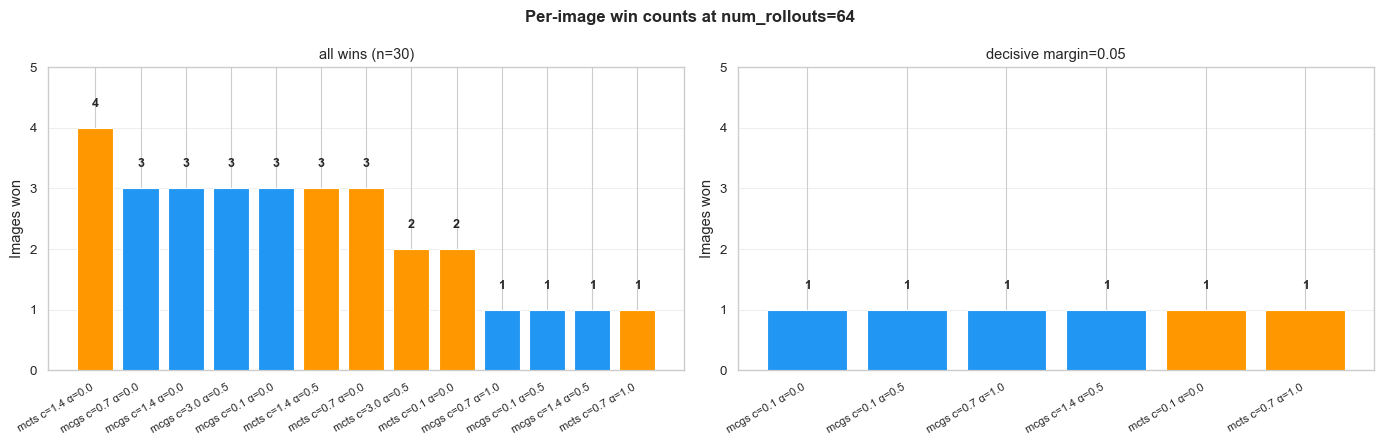

In [33]:
_top_n = child_runs_n[child_runs_n["num_rollouts"] == 64].copy()
_wins_no_top = _count_wins(_top_n, 0.0)
_wins_mg_top = _count_wins(_top_n, WIN_MARGIN)


def _cfg_label(row):
    return f"{row['algorithm']} c={row['c']} ÃŽÂ±={row['alpha']}"


_n_top_img = _top_n["image_name"].nunique()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Per-image win counts at num_rollouts=64", fontsize=12, fontweight="bold")

for ax, wins_df, title in [
    (ax1, _wins_no_top, f"all wins (n={_n_top_img})"),
    (ax2, _wins_mg_top, f"decisive margin={WIN_MARGIN}"),
]:
    if wins_df.empty:
        ax.text(0.5, 0.5, "no wins", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue
    wdf = wins_df.copy()
    wdf["label"] = wdf.apply(_cfg_label, axis=1)
    wdf = wdf.sort_values("wins", ascending=False).reset_index(drop=True)
    x = np.arange(len(wdf))
    bar_colors = [ALGO_COLOR.get(r["algorithm"], "#999") for _, r in wdf.iterrows()]
    ax.bar(x, wdf["wins"], color=bar_colors, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(wdf["label"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Images won")
    ax.set_title(title)
    ax.set_ylim(0, max(wdf["wins"].max() * 1.18, 5))
    for i, v in enumerate(wdf["wins"]):
        ax.text(
            i, v + 0.3, str(v), ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

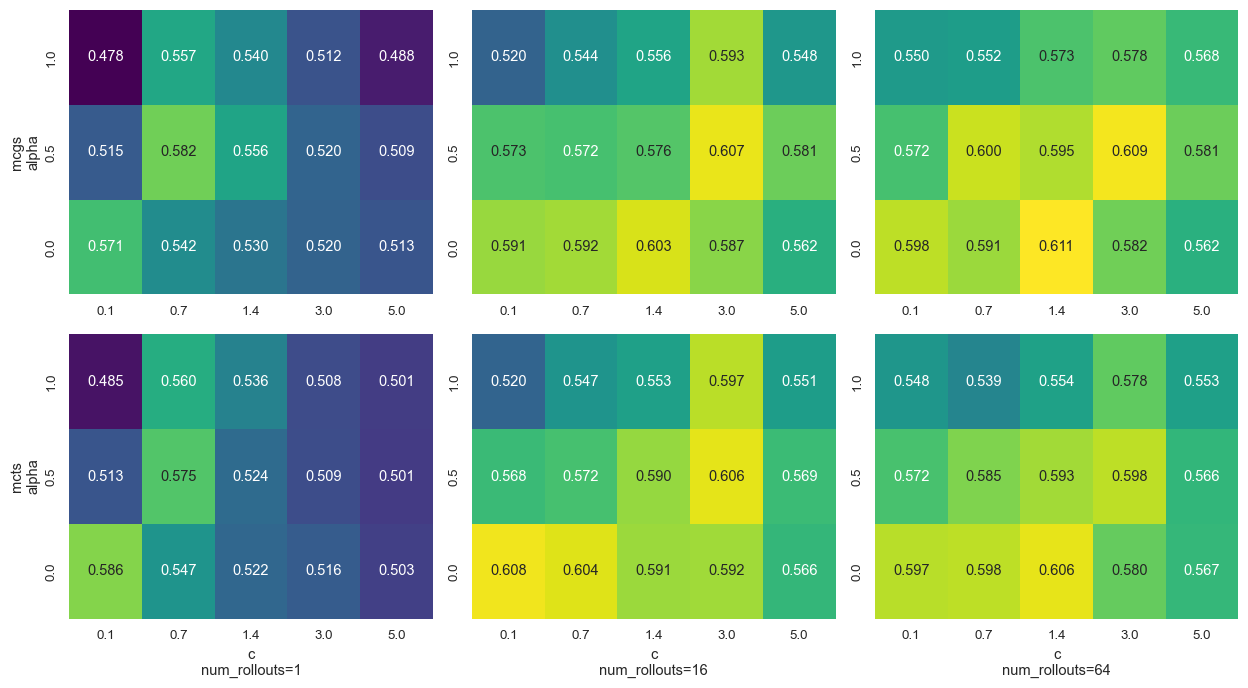

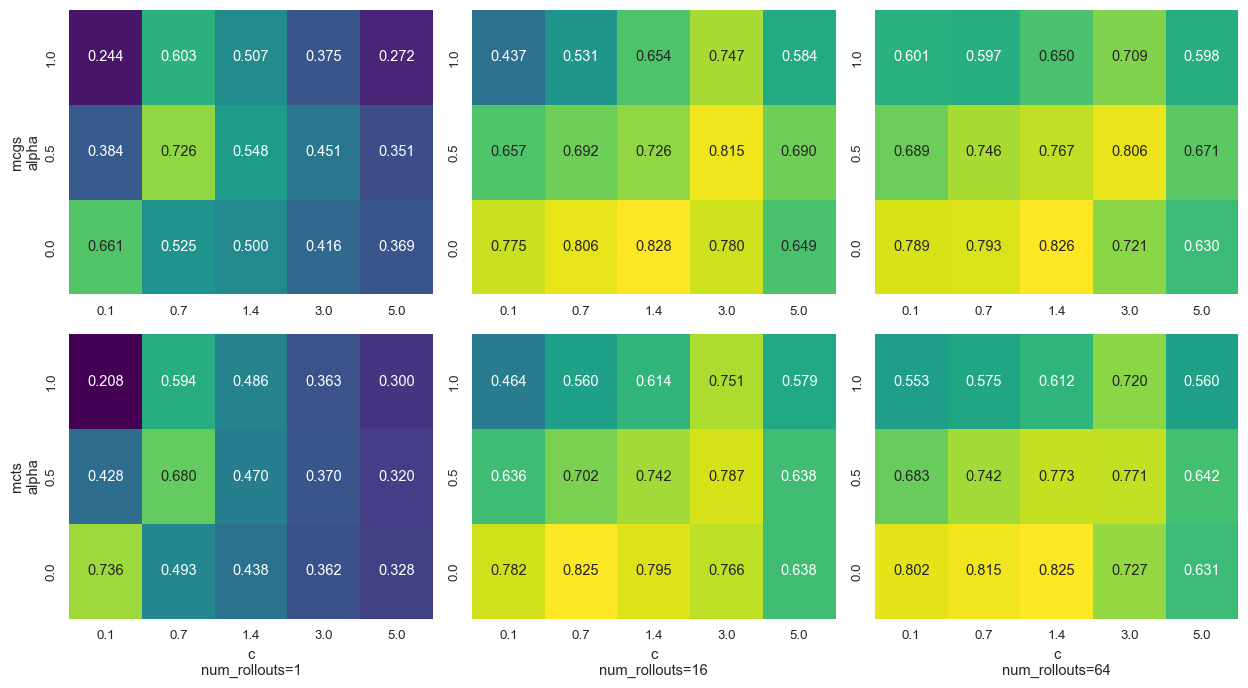

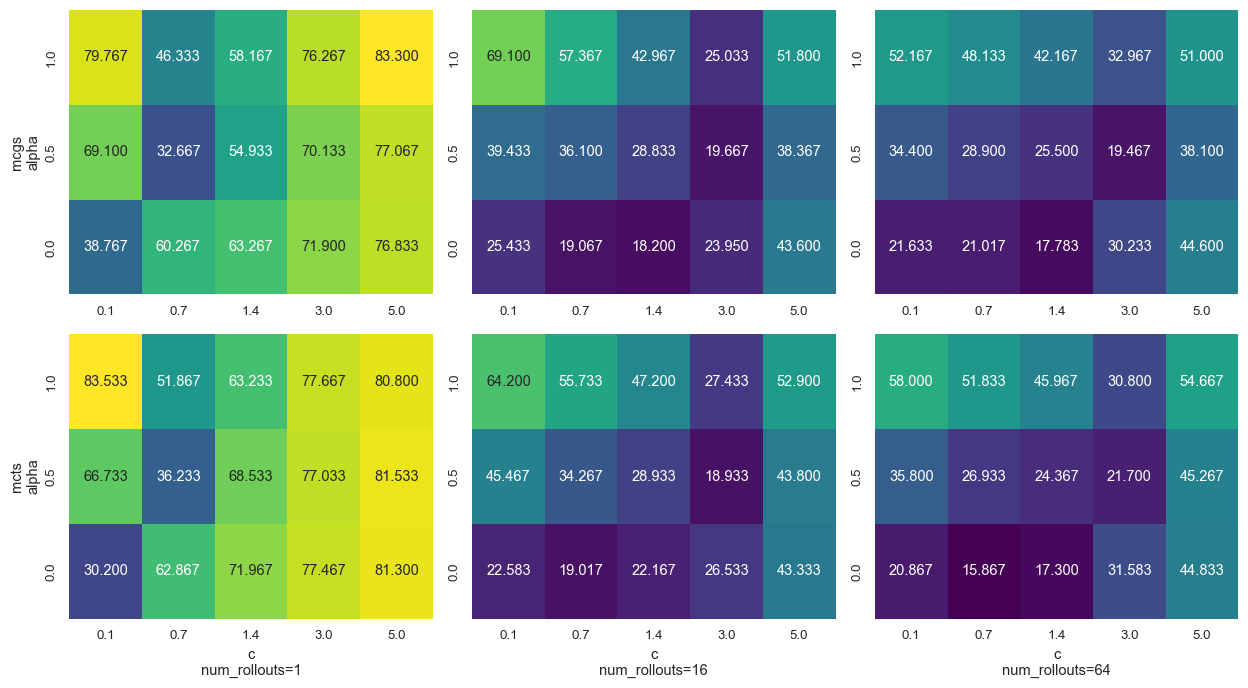

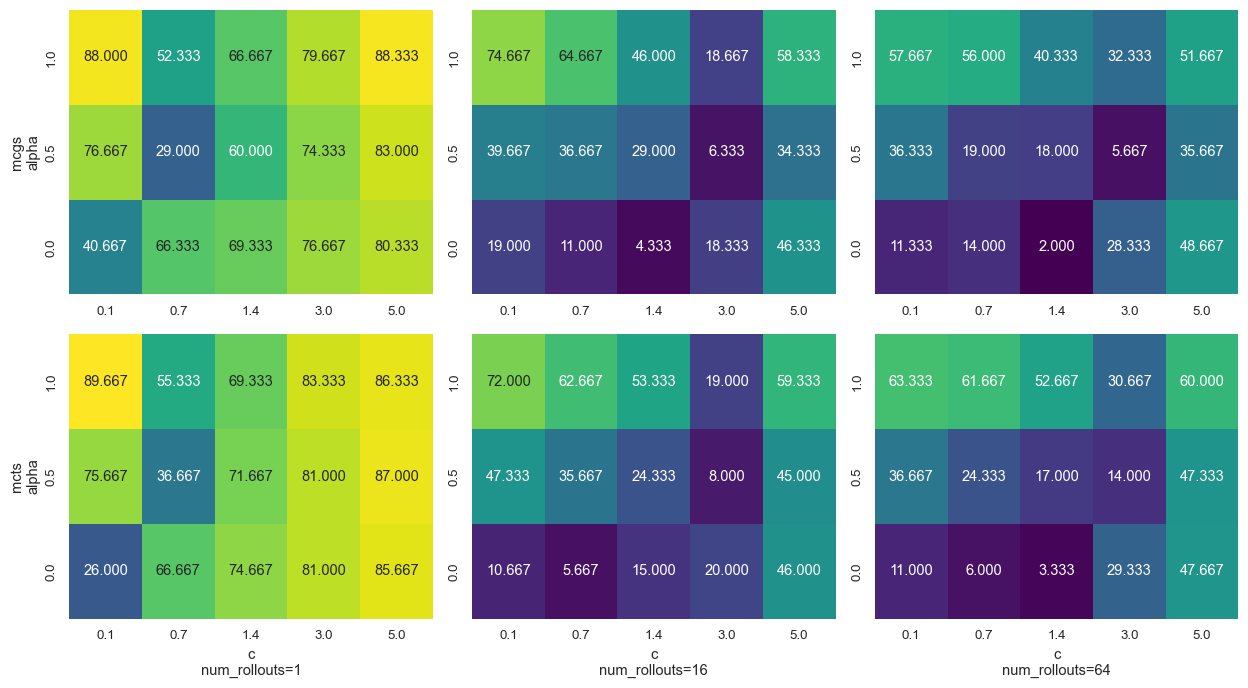

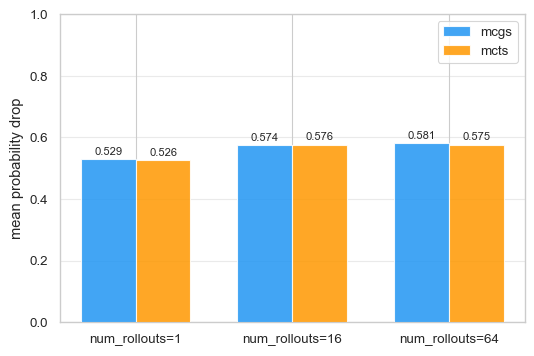

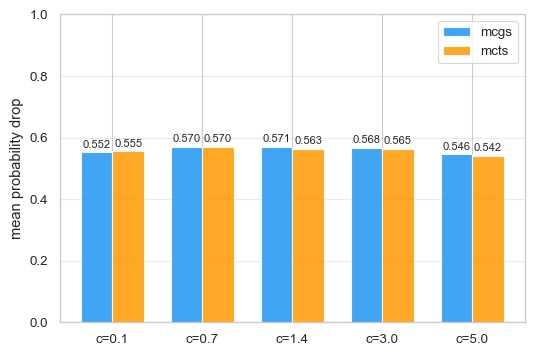

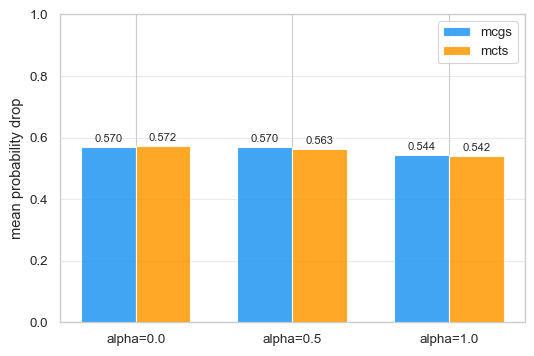

In [34]:
def plot_heatmap_grid(df: pd.DataFrame, value: str) -> None:
    algos = sorted(df["algorithm"].dropna().unique())
    rollouts = sorted(df["num_rollouts"].dropna().unique())
    fig, axes = plt.subplots(
        len(algos),
        len(rollouts),
        figsize=(4.2 * len(rollouts), 3.5 * len(algos)),
        squeeze=False,
    )
    vmin, vmax = df[value].min(), df[value].max()
    for i, algo in enumerate(algos):
        for j, rl in enumerate(rollouts):
            ax = axes[i][j]
            sub = df[(df["algorithm"] == algo) & (df["num_rollouts"] == rl)]
            if sub.empty:
                ax.set_axis_off()
                continue
            pivot = sub.pivot_table(
                index="alpha", columns="c", values=value, aggfunc="mean"
            )
            sns.heatmap(
                pivot,
                ax=ax,
                annot=True,
                fmt=".3f",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                cbar=False,
            )
            ax.invert_yaxis()
            if j == 0:
                ax.set_ylabel(f"{algo}\nalpha")
            else:
                ax.set_ylabel("")
            if i == len(algos) - 1:
                ax.set_xlabel(f"c\nnum_rollouts={int(rl)}")
            else:
                ax.set_xlabel("")
    fig.tight_layout()
    plt.show()


# Heatmap grids for each score
plot_heatmap_grid(agg, "prob_drop_mean")
plot_heatmap_grid(norm_sum, "norm_score_mean")
plot_heatmap_grid(rank_sum, "mean_rank")
plot_heatmap_grid(combined, "final_score")

# Mean prob_drop bar charts (left panels)
rollout_vals = sorted(agg["num_rollouts"].unique())
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(rollout_vals))
width = 0.35
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = agg[agg["algorithm"] == algo].groupby("num_rollouts")["prob_drop_mean"].mean()
    sub = sub.reindex(rollout_vals)
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"num_rollouts={int(r)}" for r in rollout_vals])
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.show()

c_vals = sorted(agg["c"].unique())
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(c_vals))
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = agg[agg["algorithm"] == algo].groupby("c")["prob_drop_mean"].mean()
    sub = sub.reindex(c_vals)
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"c={c}" for c in c_vals])
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.show()

alpha_vals = sorted(agg["alpha"].unique())
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(alpha_vals))
for i, algo in enumerate(["mcgs", "mcts"]):
    sub = agg[agg["algorithm"] == algo].groupby("alpha")["prob_drop_mean"].mean()
    sub = sub.reindex(alpha_vals)
    bars = ax.bar(
        x + i * width,
        sub.values,
        width,
        label=algo,
        color=ALGO_COLOR[algo],
        alpha=0.85,
        zorder=3,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"alpha={a}" for a in alpha_vals])
ax.set_ylabel("mean probability drop")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.show()